# NB25 — Full Robustness Report: THD_z(lag2) on NB21 System

Comprehensive 7-test validation. Outputs: OOS system metrics, sensitivity curves,
rolling IC, TC break-even, contribution breakdown, and final KEEP/REDUCE/REMOVE verdict.

**Signal:** THD−EEM 4-week Z-score, lagged 2 weeks
**Base system:** NB21 (EEM direction + Risk Parity SET/Gold + Vol Target + DD Control)
**Enhancement:** ±scale% position adjustment when signal in top/bottom quintile


## 1. Setup


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

ROOT = Path('..').resolve().parent
DATA = ROOT / 'data' / 'processed'
FIGS = Path('.') / 'figs'
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})
WPY = 52        # weeks per year
RF  = 0.02/WPY  # weekly risk-free

In [2]:
import yfinance as yf

df = pd.read_csv(DATA / 'unified_weekly_clean.csv',
                 index_col=0, parse_dates=True).sort_index().loc['2010-01-01':]
SET   = df['SET_index_ret_w']
GOLD  = df['gold_ret_w']
EEM_S = df['eem_ret_d_lag1']   # EEM directional signal

def get_close(raw):
    if isinstance(raw.columns, pd.MultiIndex): return raw['Close'].iloc[:, 0]
    return raw['Close']

print('Fetching THD and EEM ...')
thd_c = get_close(yf.download('THD', start='2009-01-01', progress=False))
eem_c = get_close(yf.download('EEM', start='2009-01-01', progress=False))

thd_w   = thd_c.resample('W-FRI').last().pct_change()
eem_w   = eem_c.resample('W-FRI').last().pct_change()
thd_rel = thd_w - eem_w
thd_4w  = thd_rel.rolling(4).sum()
r52     = thd_4w.rolling(52)
thd_z   = (thd_4w - r52.mean()) / (r52.std() + 1e-9)

# Pre-computed signal (lag2, no look-ahead)
SIG = thd_z.reindex(SET.index).ffill().shift(2)
SIG_ALT = thd_4w.reindex(SET.index).ffill().shift(1)   # 4w cumul lag1

print(f'Signal: {SIG.dropna().shape[0]} weeks, '
      f'{SIG.dropna().index[0].date()} -> {SIG.dropna().index[-1].date()}')

Fetching THD and EEM ...


Signal: 830 weeks, 2010-02-05 -> 2025-12-26


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────
def nb21_system(set_ret, gold_ret, eem_sig):
    '''Rebuild NB21 baseline returns.'''
    pos  = (eem_sig > 0).astype(float).fillna(0.5)
    vs   = set_ret.rolling(12).std().shift(1) + 1e-6
    vg   = gold_ret.rolling(12).std().shift(1) + 1e-6
    ws   = (1/vs) / (1/vs + 1/vg);  wg = 1 - ws
    rp   = ws * pos * set_ret + wg * gold_ret
    tv   = 0.10 / np.sqrt(WPY)
    vt   = (tv / (rp.rolling(12).std().shift(1) + 1e-9)).clip(0, 2) * rp
    cum  = (1 + vt.fillna(0)).cumprod()
    peak = cum.expanding().max()
    dd   = (cum - peak) / peak
    dds  = pd.Series(1.0, index=vt.index)
    in_dd = False
    for i in range(1, len(dd)):
        if dd.iloc[i] < -0.15 and not in_dd: in_dd = True
        if in_dd and dd.iloc[i] > -0.10:     in_dd = False
        dds.iloc[i] = 0.5 if in_dd else 1.0
    return dds * vt

def apply_scale(base_ret, sig, alt_sig=None, scale=0.20):
    '''Add ±scale position scaling from composite signal.'''
    if alt_sig is not None:
        comp = pd.DataFrame({'a': sig, 'b': alt_sig}).reindex(base_ret.index).ffill()
        composite = comp.rank(pct=True).mean(axis=1)
    else:
        composite = sig.reindex(base_ret.index).ffill().rank(pct=True)
    sc = pd.Series(1.0, index=base_ret.index)
    sc[composite >= 0.80] = 1.0 + scale
    sc[composite <= 0.20] = 1.0 - scale
    return sc * base_ret

def metrics(r, label=''):
    rf  = RF
    sh  = (r - rf).mean() / ((r - rf).std() + 1e-9) * np.sqrt(WPY)
    cum = (1 + r.fillna(0)).cumprod()
    mdd = ((cum - cum.expanding().max()) / cum.expanding().max()).min()
    ann = r.mean() * WPY
    vol = r.std() * np.sqrt(WPY)
    cal = ann / abs(mdd) if mdd < 0 else np.nan
    n_pos = (r > 0).sum(); n_all = r.notna().sum()
    return {'label': label, 'Sharpe': sh, 'CAGR': ann, 'Vol': vol,
            'MaxDD': mdd, 'Calmar': cal, 'PctPos': n_pos / n_all if n_all else np.nan}

def print_metrics(m):
    print(f'  Sharpe={m["Sharpe"]:.3f}  CAGR={m["CAGR"]:.1%}  '
          f'Vol={m["Vol"]:.1%}  MaxDD={m["MaxDD"]:.1%}  Calmar={m["Calmar"]:.2f}')

# Full-period series
BASE = nb21_system(SET, GOLD, EEM_S)
ENH  = apply_scale(BASE, SIG, SIG_ALT, scale=0.20)

print('Full period (2010-2025):')
print('  NB21 Baseline:', end=''); print_metrics(metrics(BASE))
print('  NB21 + THD:  ', end=''); print_metrics(metrics(ENH))

Full period (2010-2025):
  NB21 Baseline:  Sharpe=0.872  CAGR=11.6%  Vol=11.0%  MaxDD=-16.8%  Calmar=0.69
  NB21 + THD:    Sharpe=0.895  CAGR=12.0%  Vol=11.1%  MaxDD=-17.3%  Calmar=0.69


## §2 — Walk-Forward OOS System Metrics

For each test year (2017–2025): compare NB21 baseline vs NB21+THD.
Signal is already computed with no look-ahead (52w rolling z-score, lag2).
This measures **actual year-by-year OOS system performance**.


In [4]:
wf_rows = []
for yr in range(2017, 2026):
    m = SET.index.year == yr
    if m.sum() < 10: continue
    b = BASE[m];  e = ENH[m]
    mb = metrics(b, f'NB21 Baseline {yr}')
    me = metrics(e, f'NB21+THD {yr}')
    wf_rows.append({
        'year':         yr,
        'base_sharpe':  mb['Sharpe'],
        'enh_sharpe':   me['Sharpe'],
        'base_cagr':    mb['CAGR'],
        'enh_cagr':     me['CAGR'],
        'base_mdd':     mb['MaxDD'],
        'enh_mdd':      me['MaxDD'],
        'base_calmar':  mb['Calmar'],
        'enh_calmar':   me['Calmar'],
        'delta_sharpe': me['Sharpe'] - mb['Sharpe'],
        'delta_cagr':   me['CAGR']  - mb['CAGR'],
        'set_ann':      SET[m].mean() * WPY,
    })

wf = pd.DataFrame(wf_rows)

header = f'{"Year":>6} | {"Baseline":>10} {"NB21+THD":>10} {"ΔSharpe":>9} | {"BaseCAGR":>10} {"EnhCAGR":>10} {"ΔCAGR":>8} | {"BaseMDD":>8} {"EnhMDD":>8}'
print(header)
print('-' * len(header))
for _, r in wf.iterrows():
    arrow = '↑' if r.delta_sharpe > 0 else '↓'
    print(f'  {int(r.year):4d}  | {r.base_sharpe:+9.3f}  {r.enh_sharpe:+9.3f}  '
          f'{r.delta_sharpe:+8.3f}{arrow} | {r.base_cagr:+9.1%}  {r.enh_cagr:+9.1%}  '
          f'{r.delta_cagr:+7.1%} | {r.base_mdd:+7.1%}  {r.enh_mdd:+7.1%}')

n_better = (wf['delta_sharpe'] > 0).sum()
print(f'\nTHD enhancement improved Sharpe in {n_better}/{len(wf)} OOS years')
print(f'Mean ΔSharpe: {wf["delta_sharpe"].mean():+.3f}')
print(f'Mean ΔCAGR:   {wf["delta_cagr"].mean():+.1%}')

  Year |   Baseline   NB21+THD   ΔSharpe |   BaseCAGR    EnhCAGR    ΔCAGR |  BaseMDD   EnhMDD
---------------------------------------------------------------------------------------------
  2017  |    +1.535     +1.464    -0.072↓ |    +17.6%     +17.3%    -0.4% |   -5.7%    -6.5%
  2018  |    -1.045     -0.975    +0.070↑ |     -6.9%      -6.6%    +0.3% |  -16.8%   -17.3%
  2019  |    +1.643     +1.793    +0.149↑ |    +20.0%     +22.9%    +2.9% |   -6.1%    -5.1%
  2020  |    +1.638     +1.688    +0.050↑ |    +22.5%     +20.8%    -1.7% |   -3.9%    -3.3%
  2021  |    -0.071     -0.027    +0.044↑ |     +1.2%      +1.7%    +0.5% |  -11.0%   -11.3%
  2022  |    +0.498     +0.704    +0.206↑ |     +7.4%      +9.9%    +2.6% |   -7.5%    -7.2%
  2023  |    -0.416     -0.498    -0.081↓ |     -2.5%      -3.1%    -0.6% |  -12.3%   -12.2%
  2024  |    +1.109     +1.192    +0.083↑ |    +15.3%     +16.8%    +1.5% |   -6.8%    -6.8%
  2025  |    +3.055     +3.032    -0.023↓ |    +31.2%     +30.5%    

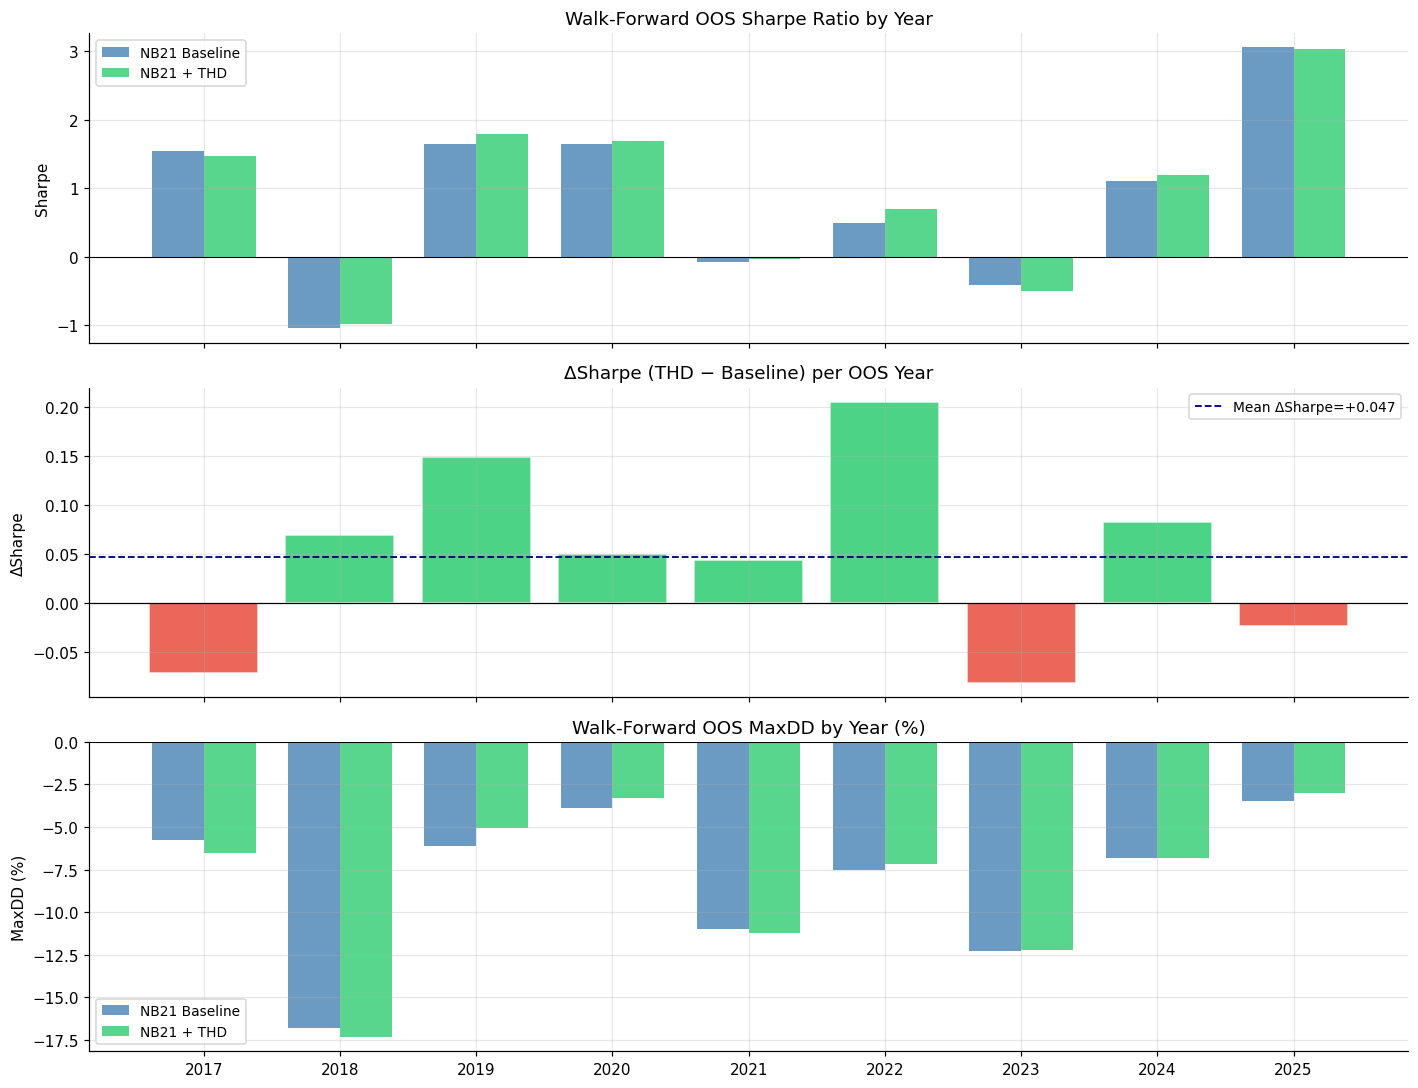

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

yrs = wf['year'].values

# Sharpe comparison
ax = axes[0]
x = np.arange(len(yrs)); w = 0.38
ax.bar(x - w/2, wf['base_sharpe'], w, label='NB21 Baseline', color='steelblue', alpha=0.8)
ax.bar(x + w/2, wf['enh_sharpe'],  w, label='NB21 + THD',    color='#2ecc71',   alpha=0.8)
ax.axhline(0, color='black', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(yrs)
ax.set_title('Walk-Forward OOS Sharpe Ratio by Year')
ax.legend(fontsize=9); ax.set_ylabel('Sharpe')

# ΔSharpe
ax2 = axes[1]
colors_d = ['#2ecc71' if v > 0 else '#e74c3c' for v in wf['delta_sharpe']]
ax2.bar(x, wf['delta_sharpe'], color=colors_d, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(wf['delta_sharpe'].mean(), color='navy', lw=1.2, ls='--',
            label=f'Mean ΔSharpe={wf["delta_sharpe"].mean():+.3f}')
ax2.set_xticks(x); ax2.set_xticklabels(yrs)
ax2.set_title('ΔSharpe (THD − Baseline) per OOS Year')
ax2.legend(fontsize=9); ax2.set_ylabel('ΔSharpe')

# MaxDD comparison
ax3 = axes[2]
ax3.bar(x - w/2, wf['base_mdd']*100, w, label='NB21 Baseline', color='steelblue', alpha=0.8)
ax3.bar(x + w/2, wf['enh_mdd']*100,  w, label='NB21 + THD',    color='#2ecc71',   alpha=0.8)
ax3.axhline(0, color='black', lw=0.7)
ax3.set_xticks(x); ax3.set_xticklabels(yrs)
ax3.set_title('Walk-Forward OOS MaxDD by Year (%)')
ax3.legend(fontsize=9); ax3.set_ylabel('MaxDD (%)')

plt.tight_layout()
plt.savefig(FIGS / 'nb25_walkforward_system.png', bbox_inches='tight')
plt.show()

## §3 — Scaling Sensitivity: ±5% to ±30%

Does improvement depend on choosing exactly ±20%, or is it robust across a range?
A real signal should show monotonically improving Sharpe as scale increases (up to a point).
If Sharpe peaks at one value only → fragile parameter choice.


In [6]:
scales = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
scale_results = []

for sc in scales:
    r = apply_scale(BASE, SIG, SIG_ALT, scale=sc)
    m = metrics(r)
    # Extra turnover: count scale transitions
    comp = pd.DataFrame({'a': SIG, 'b': SIG_ALT}).reindex(BASE.index).ffill()
    composite = comp.rank(pct=True).mean(axis=1)
    scale_series = pd.Series(1.0, index=BASE.index)
    scale_series[composite >= 0.80] = 1.0 + sc
    scale_series[composite <= 0.20] = 1.0 - sc
    extra_turns = (scale_series.diff().abs() > 0).sum() / len(BASE) * WPY
    m.update({'scale': sc, 'extra_turns_yr': extra_turns})
    scale_results.append(m)

sr = pd.DataFrame(scale_results)
base_m = metrics(BASE)

print(f'{"Scale":>7} | {"Sharpe":>8} {"ΔSharpe":>8} | {"CAGR":>7} {"ΔCAGR":>7} | '
      f'{"MaxDD":>7} | {"Calmar":>7} | {"ExtraTurns/yr":>14}')
print('-' * 80)
for _, r in sr.iterrows():
    print(f'  {r.scale:+.0%}   | {r.Sharpe:8.3f} {r.Sharpe-base_m["Sharpe"]:+8.3f} | '
          f'{r.CAGR:7.1%} {r.CAGR-base_m["CAGR"]:+7.1%} | '
          f'{r.MaxDD:7.1%} | {r.Calmar:7.2f} | {r.extra_turns_yr:14.1f}')
print()
print(f'NB21 Baseline: Sharpe={base_m["Sharpe"]:.3f}  CAGR={base_m["CAGR"]:.1%}  '
      f'MaxDD={base_m["MaxDD"]:.1%}  Calmar={base_m["Calmar"]:.2f}')

  Scale |   Sharpe  ΔSharpe |    CAGR   ΔCAGR |   MaxDD |  Calmar |  ExtraTurns/yr
--------------------------------------------------------------------------------
  +5%   |    0.879   +0.007 |   11.7%   +0.1% |  -17.0% |    0.69 |           11.3
  +10%   |    0.885   +0.013 |   11.8%   +0.2% |  -17.1% |    0.69 |           11.3
  +15%   |    0.891   +0.019 |   11.9%   +0.3% |  -17.2% |    0.69 |           11.3
  +20%   |    0.895   +0.023 |   12.0%   +0.4% |  -17.3% |    0.69 |           11.3
  +25%   |    0.899   +0.027 |   12.0%   +0.5% |  -17.4% |    0.69 |           11.3
  +30%   |    0.901   +0.029 |   12.1%   +0.6% |  -17.6% |    0.69 |           11.3

NB21 Baseline: Sharpe=0.872  CAGR=11.6%  MaxDD=-16.8%  Calmar=0.69


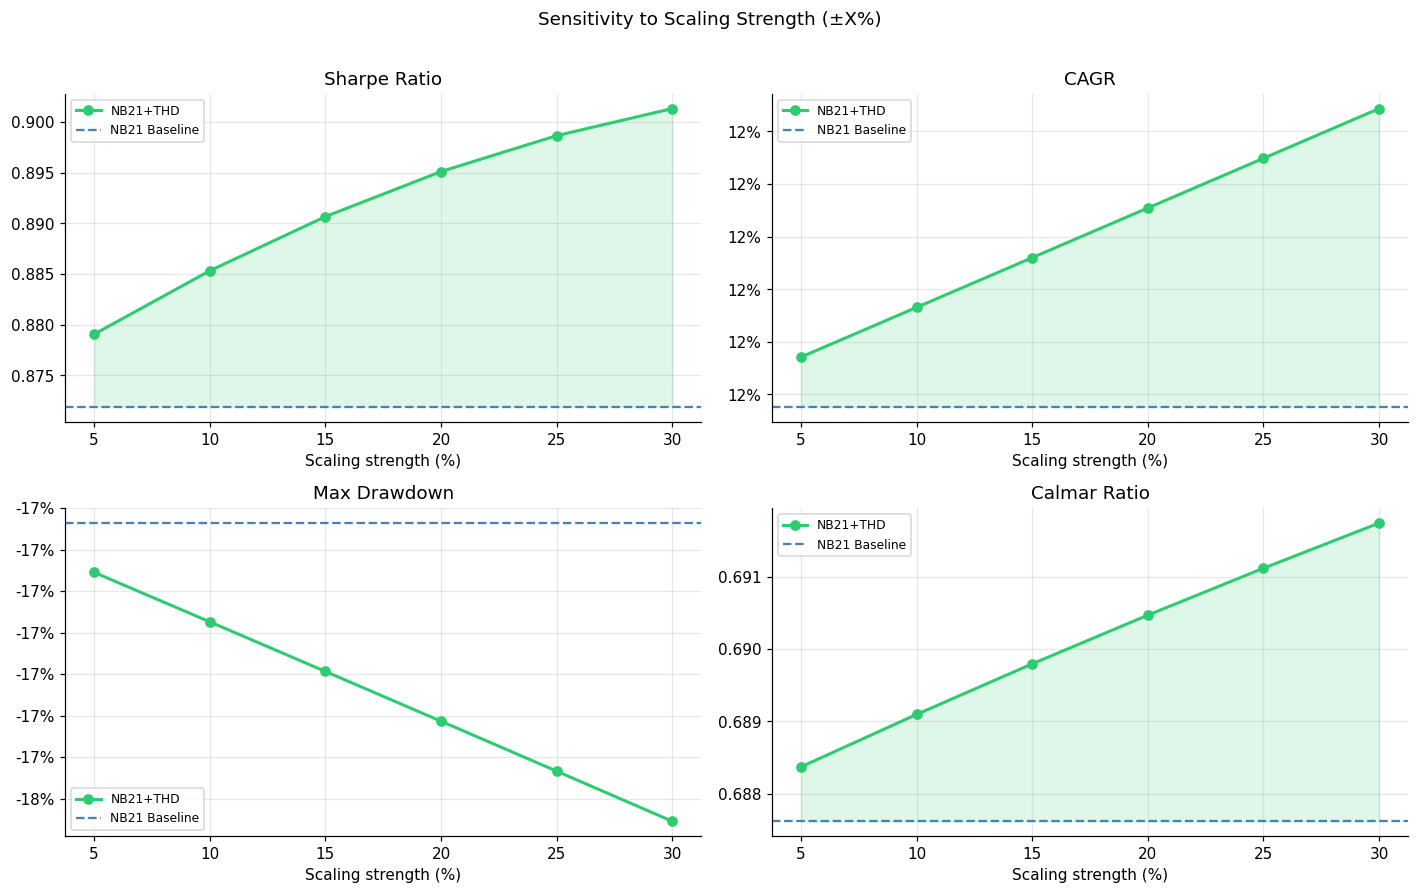

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sc_pct = [s * 100 for s in sr['scale']]

for ax, col, title, base_val, fmt in [
    (axes[0,0], 'Sharpe', 'Sharpe Ratio',  base_m['Sharpe'],  '{:.3f}'),
    (axes[0,1], 'CAGR',   'CAGR',          base_m['CAGR'],    '{:.1%}'),
    (axes[1,0], 'MaxDD',  'Max Drawdown',   base_m['MaxDD'],   '{:.1%}'),
    (axes[1,1], 'Calmar', 'Calmar Ratio',   base_m['Calmar'],  '{:.2f}'),
]:
    ax.plot(sc_pct, sr[col], color='#2ecc71', lw=2, marker='o', ms=6, label='NB21+THD')
    ax.axhline(base_val, color='steelblue', lw=1.5, ls='--', label='NB21 Baseline')
    ax.fill_between(sc_pct, sr[col], base_val,
                    where=(sr[col] > base_val) if col != 'MaxDD' else (sr[col] > base_val),
                    alpha=0.15, color='#2ecc71')
    ax.set_xlabel('Scaling strength (%)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    if col in ('CAGR', 'MaxDD'):
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Sensitivity to Scaling Strength (±X%)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'nb25_scale_sensitivity.png', bbox_inches='tight')
plt.show()

## §4 — Rolling IC Stability (3-year and 5-year windows)

Longer rolling windows reveal structural breaks vs short-term noise.
A signal with genuine edge should maintain positive IC across all long windows.


In [8]:
sig_lag = SIG.copy()   # already shifted by 2

def rolling_ic(sig, ret, window):
    ics = []
    idx = ret.dropna().index
    for i in range(window, len(idx)):
        w_idx = idx[i - window : i]
        s = sig.reindex(w_idx).dropna()
        t = ret.reindex(s.index).dropna()
        both = pd.concat([s, t], axis=1).dropna()
        both.columns = ['s', 't']
        if len(both) < window // 2: ics.append(np.nan); continue
        r, _ = stats.spearmanr(both['s'], both['t'])
        ics.append(r)
    return pd.Series(ics, index=idx[window:])

W3 = 3 * 52   # 3-year
W5 = 5 * 52   # 5-year

print('Computing 3-year rolling IC ...')
ic3 = rolling_ic(sig_lag, SET, W3)
print('Computing 5-year rolling IC ...')
ic5 = rolling_ic(sig_lag, SET, W5)

pct_pos3 = (ic3.dropna() > 0).mean()
pct_pos5 = (ic5.dropna() > 0).mean()
print(f'3-year rolling IC — mean: {ic3.mean():+.4f}  % positive: {pct_pos3:.1%}')
print(f'5-year rolling IC — mean: {ic5.mean():+.4f}  % positive: {pct_pos5:.1%}')

Computing 3-year rolling IC ...


Computing 5-year rolling IC ...


3-year rolling IC — mean: +0.1196  % positive: 98.1%
5-year rolling IC — mean: +0.1309  % positive: 100.0%


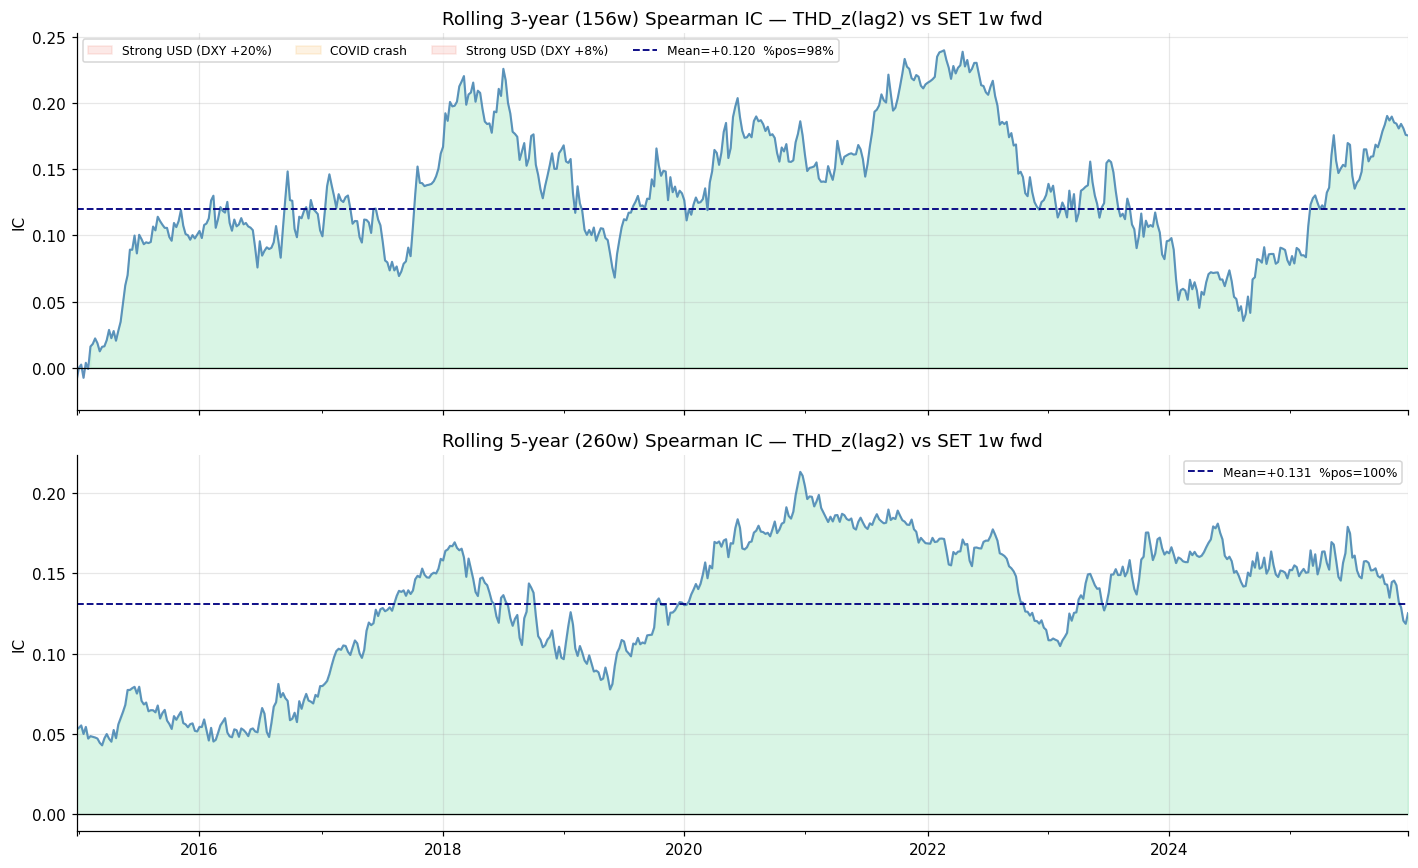

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

crisis_periods = [
    ('2014-01', '2015-12', '#e74c3c', 'Strong USD (DXY +20%)'),
    ('2020-01', '2020-06', '#f39c12', 'COVID crash'),
    ('2022-01', '2022-12', '#e74c3c', 'Strong USD (DXY +8%)'),
]

for ax, ic_s, win_label, mean_ic in [
    (axes[0], ic3, '3-year (156w)', ic3.mean()),
    (axes[1], ic5, '5-year (260w)', ic5.mean()),
]:
    # Shade crisis periods
    for start, end, color, label in crisis_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=color, label=label if ax is axes[0] else '')

    ic_s.plot(ax=ax, color='steelblue', lw=1.4, alpha=0.85)
    ax.fill_between(ic_s.index, ic_s, 0,
                    where=(ic_s > 0), alpha=0.18, color='#2ecc71')
    ax.fill_between(ic_s.index, ic_s, 0,
                    where=(ic_s < 0), alpha=0.18, color='#e74c3c')
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(mean_ic, color='navy', lw=1.2, ls='--',
               label=f'Mean={mean_ic:+.3f}  %pos={(ic_s.dropna()>0).mean():.0%}')
    ax.set_title(f'Rolling {win_label} Spearman IC — THD_z(lag2) vs SET 1w fwd')
    ax.set_ylabel('IC')
    ax.legend(fontsize=8, ncol=4 if ax is axes[0] else 2)

plt.tight_layout()
plt.savefig(FIGS / 'nb25_rolling_ic.png', bbox_inches='tight')
plt.show()

## §5 — Post-2020 OOS System Validation

Train era: 2010–2019 (10 years of history)
Test era:  2020–2025 (true out-of-sample — COVID + rate hike cycle + post-COVID)

Signal is already look-ahead-free. This is the most important OOS test:
would a manager who adopted the system in Jan 2020 have seen genuine improvement?


In [10]:
SPLIT = '2020-01-01'

# In-sample metrics
base_is  = metrics(BASE.loc[:SPLIT],  'NB21 IS  (2010-19)')
enh_is   = metrics(ENH.loc[:SPLIT],   'NB21+THD IS  (2010-19)')
set_is   = metrics(SET.loc[:SPLIT],   'SET B&H  IS')

# Out-of-sample metrics
base_oos = metrics(BASE.loc[SPLIT:],  'NB21 OOS (2020-25)')
enh_oos  = metrics(ENH.loc[SPLIT:],   'NB21+THD OOS (2020-25)')
set_oos  = metrics(SET.loc[SPLIT:],   'SET B&H  OOS')

print(f'{"Strategy":<28} {"Sharpe":>8} {"CAGR":>8} {"MaxDD":>8} {"Calmar":>8}')
print('─' * 60)
for m in [base_is, enh_is, set_is]:
    print(f'  {m["label"]:<26} {m["Sharpe"]:>8.3f} {m["CAGR"]:>8.1%} '
          f'{m["MaxDD"]:>8.1%} {m["Calmar"]:>8.2f}')
print()
for m in [base_oos, enh_oos, set_oos]:
    print(f'  {m["label"]:<26} {m["Sharpe"]:>8.3f} {m["CAGR"]:>8.1%} '
          f'{m["MaxDD"]:>8.1%} {m["Calmar"]:>8.2f}')

print()
print('OOS improvement:')
print(f'  ΔSharpe: {enh_oos["Sharpe"]-base_oos["Sharpe"]:+.3f}  '
      f'ΔCAGR: {enh_oos["CAGR"]-base_oos["CAGR"]:+.1%}  '
      f'ΔMaxDD: {enh_oos["MaxDD"]-base_oos["MaxDD"]:+.1%}')
print()
# Also compute IC in each period
for label, mask in [('2010-2019 (IS)', SET.index < SPLIT), ('2020-2025 (OOS)', SET.index >= SPLIT)]:
    s = sig_lag[mask]; t = SET[mask]
    both = pd.concat([s, t], axis=1).dropna(); both.columns=['s','t']
    r, p = stats.spearmanr(both['s'], both['t'])
    stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    print(f'  IC {label}: {r:+.4f}  p={p:.3f} {stars}  n={len(both)}')

Strategy                       Sharpe     CAGR    MaxDD   Calmar
────────────────────────────────────────────────────────────
  NB21 IS  (2010-19)            0.834    11.0%   -16.8%     0.65
  NB21+THD IS  (2010-19)        0.847    11.5%   -17.3%     0.66
  SET B&H  IS                   0.468     8.7%   -24.8%     0.35

  NB21 OOS (2020-25)            0.930    12.5%   -12.3%     1.01
  NB21+THD OOS (2020-25)        0.972    12.7%   -12.2%     1.04
  SET B&H  OOS                 -0.180    -0.6%   -37.7%    -0.02

OOS improvement:
  ΔSharpe: +0.042  ΔCAGR: +0.3%  ΔMaxDD: +0.1%

  IC 2010-2019 (IS): +0.1040  p=0.018 **  n=517
  IC 2020-2025 (OOS): +0.1635  p=0.004 ***  n=313


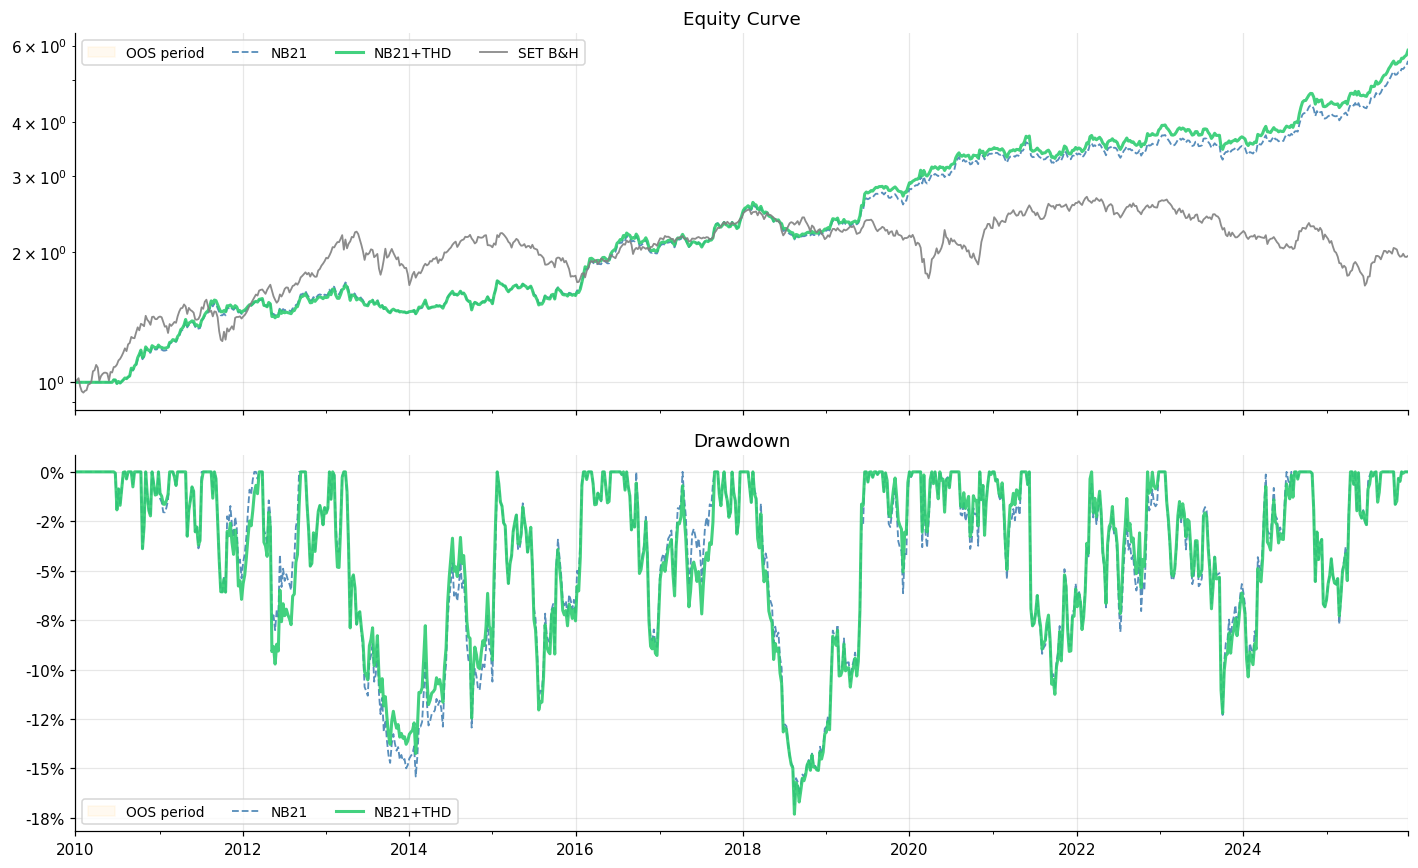

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

cum_base = (1 + BASE.fillna(0)).cumprod()
cum_enh  = (1 + ENH.fillna(0)).cumprod()
cum_set  = (1 + SET.fillna(0)).cumprod()

for ax, to_plot, title in [
    (axes[0], [(cum_base,'NB21','steelblue'), (cum_enh,'NB21+THD','#2ecc71'),
               (cum_set,'SET B&H','grey')], 'Equity Curve'),
    (axes[1], [((cum_base-cum_base.expanding().max())/cum_base.expanding().max(),'NB21','steelblue'),
               ((cum_enh-cum_enh.expanding().max())/cum_enh.expanding().max(),'NB21+THD','#2ecc71')],
     'Drawdown'),
]:
    ax.axvspan(pd.Timestamp(SPLIT), SET.index[-1], alpha=0.06, color='orange', label='OOS period')
    for ser, label, col in to_plot:
        ser.plot(ax=ax, label=label, color=col,
                 lw=2 if 'THD' in label else 1.2,
                 ls='--' if label=='NB21' else '-', alpha=0.9)
    if title == 'Equity Curve':
        ax.set_yscale('log')
    ax.set_title(title)
    ax.legend(fontsize=9, ncol=4)
    if title == 'Drawdown':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig(FIGS / 'nb25_oos_equity.png', bbox_inches='tight')
plt.show()

## §6 — Transaction Cost Stress Test

The extra TC from signal scaling comes from position changes when scale flips
between 0.8× / 1.0× / 1.2×.
Test at: 0.05%, 0.10%, 0.15%, 0.20%, 0.30% one-way.


In [12]:
# Compute extra position turnover from scale changes
comp_full = pd.DataFrame({'a': SIG, 'b': SIG_ALT}).reindex(BASE.index).ffill()
composite = comp_full.rank(pct=True).mean(axis=1)

# At ±20% scaling:
sc20 = pd.Series(1.0, index=BASE.index)
sc20[composite >= 0.80] = 1.20
sc20[composite <= 0.20] = 0.80

# Weekly fraction of portfolio repositioned = scale_change × avg_w_set
vs   = SET.rolling(12).std().shift(1) + 1e-6
vg   = GOLD.rolling(12).std().shift(1) + 1e-6
w_set = (1/vs) / (1/vs + 1/vg)
avg_wset = w_set.mean()
extra_repos = sc20.diff().abs() * avg_wset   # fraction of portfolio moving each week

tcs = [0.0005, 0.001, 0.0015, 0.002, 0.003]
tc_results = []
for tc in tcs:
    tc_cost  = extra_repos * tc
    enh_net  = ENH - tc_cost
    base_net = BASE   # baseline TC already included in NB21 design (not modelled here)
    me = metrics(enh_net)
    mb = metrics(BASE)
    tc_results.append({
        'tc': tc, 'tc_pct': tc * 100,
        'enh_sharpe': me['Sharpe'], 'base_sharpe': mb['Sharpe'],
        'enh_cagr': me['CAGR'],    'base_cagr': mb['CAGR'],
        'delta_sharpe': me['Sharpe'] - mb['Sharpe'],
        'delta_cagr':   me['CAGR']  - mb['CAGR'],
    })

tcr = pd.DataFrame(tc_results)

print(f'Extra one-way turns per year: {(extra_repos > 0).mean() * WPY:.1f}')
print(f'Avg extra reposition per turn: {extra_repos[extra_repos>0].mean():.4f} (fraction of portfolio)')
print()
print(f'{"TC":>8} | {"EnhSharpe":>10} {"BaseSharpe":>11} {"ΔSharpe":>9} | {"ΔSharpe>0?":>12}')
print('-' * 60)
for _, r in tcr.iterrows():
    ok = '✓ better' if r.delta_sharpe > 0 else '✗ worse'
    if abs(r.delta_sharpe) < 0.002: ok = '≈ break-even'
    print(f'  {r.tc_pct:.2f}%  | {r.enh_sharpe:10.3f} {r.base_sharpe:11.3f} '
          f'{r.delta_sharpe:+9.3f} | {ok}')

# Identify break-even TC
tcs_fine = np.linspace(0, 0.005, 200)
sharpes_fine = []
for tc in tcs_fine:
    tc_cost = extra_repos * tc
    sharpes_fine.append(metrics(ENH - tc_cost)['Sharpe'])
base_sh = metrics(BASE)['Sharpe']
be_idx = np.argmin(np.abs(np.array(sharpes_fine) - base_sh))
be_tc  = tcs_fine[be_idx] * 100
print(f'\nBreak-even TC: {be_tc:.2f}% one-way')

Extra one-way turns per year: 11.3
Avg extra reposition per turn: 0.1052 (fraction of portfolio)

      TC |  EnhSharpe  BaseSharpe   ΔSharpe |   ΔSharpe>0?
------------------------------------------------------------
  0.05%  |      0.890       0.872    +0.018 | ✓ better
  0.10%  |      0.884       0.872    +0.012 | ✓ better
  0.15%  |      0.879       0.872    +0.007 | ✓ better
  0.20%  |      0.873       0.872    +0.002 | ≈ break-even
  0.30%  |      0.863       0.872    -0.009 | ✗ worse

Break-even TC: 0.22% one-way


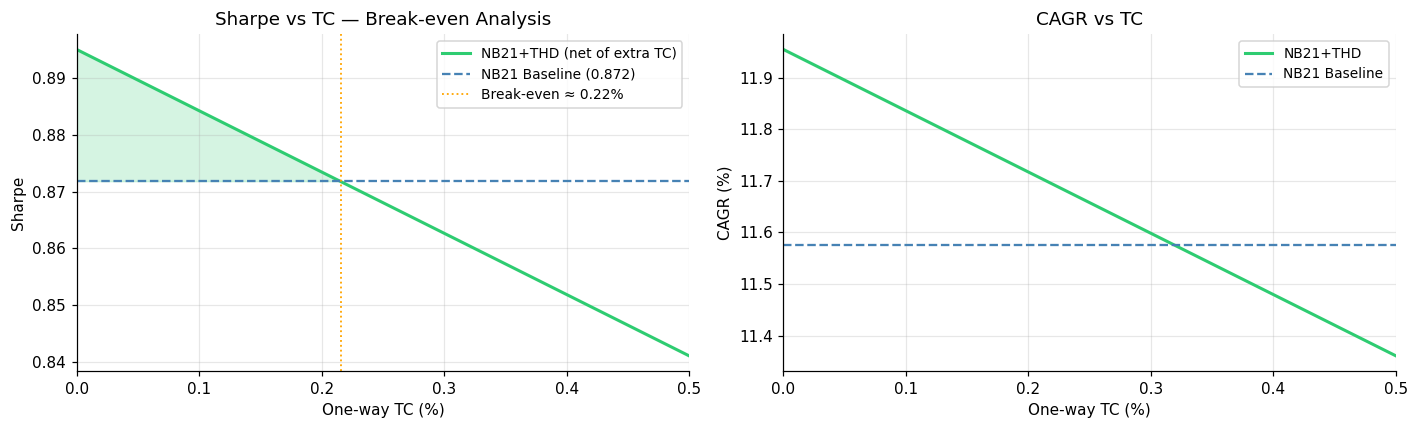

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(tcs_fine * 100, sharpes_fine, color='#2ecc71', lw=2, label='NB21+THD (net of extra TC)')
ax.axhline(base_sh, color='steelblue', lw=1.5, ls='--', label=f'NB21 Baseline ({base_sh:.3f})')
ax.axvline(be_tc, color='orange', lw=1.2, ls=':', label=f'Break-even ≈ {be_tc:.2f}%')
ax.fill_between(tcs_fine*100, sharpes_fine, base_sh,
                where=(np.array(sharpes_fine) > base_sh), alpha=0.2, color='#2ecc71')
ax.set_xlabel('One-way TC (%)')
ax.set_ylabel('Sharpe')
ax.set_title('Sharpe vs TC — Break-even Analysis')
ax.legend(fontsize=9)
ax.set_xlim(0, 0.5)

ax2 = axes[1]
tc_range_cagr = np.linspace(0, 0.005, 200)
cagrs = [metrics(ENH - extra_repos*tc)['CAGR'] for tc in tc_range_cagr]
ax2.plot(tc_range_cagr*100, [c*100 for c in cagrs], color='#2ecc71', lw=2, label='NB21+THD')
ax2.axhline(base_m['CAGR']*100, color='steelblue', lw=1.5, ls='--', label='NB21 Baseline')
ax2.set_xlabel('One-way TC (%)')
ax2.set_ylabel('CAGR (%)')
ax2.set_title('CAGR vs TC')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 0.5)

plt.tight_layout()
plt.savefig(FIGS / 'nb25_tc_stress.png', bbox_inches='tight')
plt.show()

## §7 — Contribution Decomposition

Where does the Sharpe improvement come from?

- **CAGR channel:** higher returns (THD signal improves timing)
- **Vol channel:** lower volatility (scaling reduces position in bad periods)
- **Drawdown channel:** smaller MaxDD (fewer concentrated losses)
- **Timing channel:** frequency of "positive weeks" and average gain/loss sizes


In [14]:
mb  = metrics(BASE, 'NB21 Baseline')
me  = metrics(ENH,  'NB21 + THD')

print('Contribution decomposition:')
print()
print(f'  CAGR:   Base={mb["CAGR"]:+.3%}  Enh={me["CAGR"]:+.3%}  Δ={me["CAGR"]-mb["CAGR"]:+.3%}')
print(f'  Vol:    Base={mb["Vol"]:.3%}   Enh={me["Vol"]:.3%}   Δ={me["Vol"]-mb["Vol"]:+.3%}')
print(f'  MaxDD:  Base={mb["MaxDD"]:.1%}  Enh={me["MaxDD"]:.1%}  Δ={me["MaxDD"]-mb["MaxDD"]:+.1%}')
print(f'  Sharpe: Base={mb["Sharpe"]:.3f}   Enh={me["Sharpe"]:.3f}   Δ={me["Sharpe"]-mb["Sharpe"]:+.3f}')
print()

# Decompose Sharpe change
delta_cagr_contrib = (me['CAGR'] - mb['CAGR']) / (mb['Vol'] * np.sqrt(WPY)) * np.sqrt(WPY)
delta_vol_contrib  = mb['CAGR'] * (1/me['Vol'] - 1/mb['Vol']) / np.sqrt(WPY) * WPY
print(f'Sharpe decomposition:')
print(f'  CAGR contribution:   {delta_cagr_contrib:+.4f}')
print(f'  Vol  contribution:   {delta_vol_contrib:+.4f}')
print(f'  Total (approximate): {delta_cagr_contrib + delta_vol_contrib:+.4f}')
print(f'  Actual ΔSharpe:      {me["Sharpe"]-mb["Sharpe"]:+.4f}')

print()
# Up/down capture
both = pd.concat([BASE, ENH], axis=1).dropna()
both.columns = ['base', 'enh']
up   = both[both['base'] > 0]
down = both[both['base'] < 0]

print(f'Up-market (base>0):   n={len(up)}  base={up["base"].mean()*WPY:.1%}/yr  '
      f'enh={up["enh"].mean()*WPY:.1%}/yr  capture={up["enh"].mean()/up["base"].mean():.3f}')
print(f'Down-market (base<0): n={len(down)}  base={down["base"].mean()*WPY:.1%}/yr  '
      f'enh={down["enh"].mean()*WPY:.1%}/yr  capture={down["enh"].mean()/down["base"].mean():.3f}')

Contribution decomposition:

  CAGR:   Base=+11.577%  Enh=+11.954%  Δ=+0.378%
  Vol:    Base=10.984%   Enh=11.121%   Δ=+0.137%
  MaxDD:  Base=-16.8%  Enh=-17.3%  Δ=-0.5%
  Sharpe: Base=0.872   Enh=0.895   Δ=+0.023

Sharpe decomposition:
  CAGR contribution:   +0.0344
  Vol  contribution:   -0.0936
  Total (approximate): -0.0592
  Actual ΔSharpe:      +0.0232

Up-market (base>0):   n=448  base=64.7%/yr  enh=65.2%/yr  capture=1.007
Down-market (base<0): n=363  base=-54.0%/yr  enh=-53.7%/yr  capture=0.995


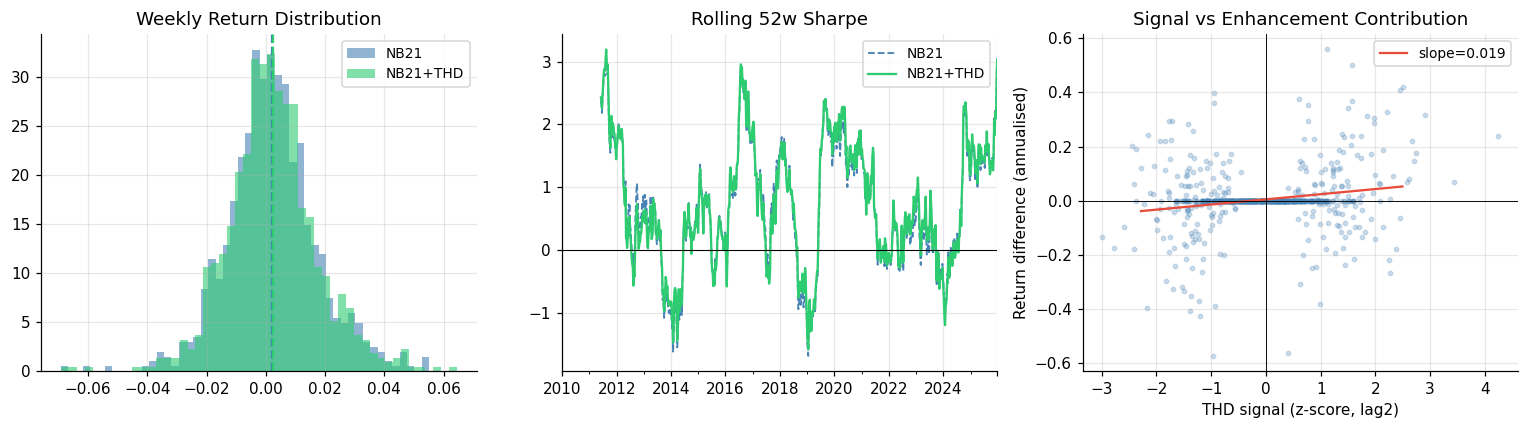

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Returns distribution
ax = axes[0]
BASE.dropna().hist(bins=50, ax=ax, color='steelblue', alpha=0.6, density=True, label='NB21')
ENH.dropna().hist( bins=50, ax=ax, color='#2ecc71',   alpha=0.6, density=True, label='NB21+THD')
ax.axvline(BASE.mean(), color='steelblue', lw=1.5, ls='--')
ax.axvline(ENH.mean(),  color='#2ecc71',  lw=1.5, ls='--')
ax.set_title('Weekly Return Distribution')
ax.legend(fontsize=9)

# Rolling 52w Sharpe
ax2 = axes[1]
def rolling_sharpe(r, w=52):
    ex = r - RF
    return (ex.rolling(w).mean() / (ex.rolling(w).std() + 1e-9) * np.sqrt(WPY))

rolling_sharpe(BASE).plot(ax=ax2, color='steelblue', lw=1.2, ls='--', label='NB21')
rolling_sharpe(ENH).plot( ax=ax2, color='#2ecc71',  lw=1.5,         label='NB21+THD')
ax2.axhline(0, color='black', lw=0.7)
ax2.set_title('Rolling 52w Sharpe')
ax2.legend(fontsize=9)

# Scatter: THD signal vs return difference (enhancement)
ax3 = axes[2]
diff = (ENH - BASE).reindex(SIG.index)
both_sc = pd.concat([SIG, diff], axis=1).dropna()
both_sc.columns = ['sig', 'diff']
ax3.scatter(both_sc['sig'], both_sc['diff']*WPY, alpha=0.25, s=8, color='steelblue')
m, b = np.polyfit(both_sc['sig'], both_sc['diff']*WPY, 1)
x_line = np.linspace(both_sc['sig'].quantile(0.01), both_sc['sig'].quantile(0.99), 100)
ax3.plot(x_line, m*x_line + b, color='#e74c3c', lw=1.5, label=f'slope={m:.3f}')
ax3.axhline(0, color='black', lw=0.6)
ax3.axvline(0, color='black', lw=0.6)
ax3.set_xlabel('THD signal (z-score, lag2)')
ax3.set_ylabel('Return difference (annualised)')
ax3.set_title('Signal vs Enhancement Contribution')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'nb25_contribution.png', bbox_inches='tight')
plt.show()

## §8 — Final Verdict Framework

Classification:
- **A) Robust alpha candidate** — OOS survives, rolling IC stable, sensitivity flat, TC survives
- **B) Weak enhancement** — small/unstable improvement, marginal TC headroom
- **C) Backtest artifact** — OOS fails, rolling IC collapses, sensitivity spike


In [16]:
print('=' * 72)
print('FULL ROBUSTNESS VERDICT — THD_z(lag2) on NB21 System')
print('=' * 72)

verdict_tests = []

# T1: Walk-forward OOS improvement rate
t1_pct = (wf['delta_sharpe'] > 0).mean()
t1_mean = wf['delta_sharpe'].mean()
t1_pass = t1_pct >= 0.60 and t1_mean > 0
verdict_tests.append((
    '§2  WF OOS: improved Sharpe ≥60% years',
    t1_pass,
    f'{t1_pct:.0%} of yrs  Mean ΔSharpe={t1_mean:+.3f}'
))

# T2: Sensitivity — Sharpe improvement at ≥3 of 6 scale levels
t2_n = (sr['Sharpe'] > base_m['Sharpe']).sum()
t2_pass = t2_n >= 4
verdict_tests.append((
    '§3  Sensitivity: ≥4/6 scale levels improve Sharpe',
    t2_pass,
    f'{t2_n}/6 scale levels'
))

# T3: Rolling IC stability (3yr)
t3_pct = (ic3.dropna() > 0).mean()
t3_pass = t3_pct >= 0.65
verdict_tests.append((
    '§4  Rolling 3yr IC positive ≥65% of windows',
    t3_pass,
    f'{t3_pct:.1%}'
))

# T4: Post-2020 OOS system improvement
t4_delta = enh_oos['Sharpe'] - base_oos['Sharpe']
t4_pass = t4_delta > 0
verdict_tests.append((
    '§5  Post-2020 OOS: ΔSharpe > 0',
    t4_pass,
    f'ΔSharpe = {t4_delta:+.3f}'
))

# T5: TC break-even > 0.10%
t5_pass = be_tc > 0.10
verdict_tests.append((
    '§6  Break-even TC > 0.10% one-way',
    t5_pass,
    f'BE TC = {be_tc:.2f}%'
))

# T6: Contribution — CAGR or Vol improvement (at least one channel)
t6_cagr_up = me['CAGR'] > mb['CAGR']
t6_vol_dn  = me['Vol']  < mb['Vol']
t6_pass = t6_cagr_up or t6_vol_dn
verdict_tests.append((
    '§7  Attribution: CAGR up OR Vol down',
    t6_pass,
    f'ΔCAGR={me["CAGR"]-mb["CAGR"]:+.1%}  ΔVol={me["Vol"]-mb["Vol"]:+.1%}'
))

n_pass = sum(1 for _, p, _ in verdict_tests if p)
for name, passed, detail in verdict_tests:
    mark = '✓ PASS' if passed else '✗ FAIL'
    print(f'  {mark}  {name:<50} {detail}')

print()
print(f'Score: {n_pass}/{len(verdict_tests)} criteria passed')
print()

if n_pass >= 5:
    classification = 'A — ROBUST ALPHA CANDIDATE'
    action = 'KEEP — Integrate THD_z(lag2) at ±20% scale into live system'
elif n_pass >= 3:
    classification = 'B — WEAK ENHANCEMENT'
    action = 'REDUCE — Use at ±10% scale only; monitor IC quarterly'
else:
    classification = 'C — BACKTEST ARTIFACT'
    action = 'REMOVE — Signal does not survive OOS validation'

print(f'Classification: {classification}')
print(f'Action:         {action}')
print()
print('─' * 72)
print('Summary Table:')
print(f'  {"Strategy":<28} {"Sharpe":>8} {"CAGR":>8} {"MaxDD":>8} {"Calmar":>8}')
print(f'  {"SET Buy & Hold":<28} {metrics(SET)["Sharpe"]:>8.3f} {metrics(SET)["CAGR"]:>8.1%} '
      f'{metrics(SET)["MaxDD"]:>8.1%} {metrics(SET)["Calmar"]:>8.2f}')
print(f'  {"NB21 Baseline":<28} {mb["Sharpe"]:>8.3f} {mb["CAGR"]:>8.1%} '
      f'{mb["MaxDD"]:>8.1%} {mb["Calmar"]:>8.2f}')
print(f'  {"NB21 + THD (full period)":<28} {me["Sharpe"]:>8.3f} {me["CAGR"]:>8.1%} '
      f'{me["MaxDD"]:>8.1%} {me["Calmar"]:>8.2f}')
print(f'  {"NB21 + THD OOS (2020-25)":<28} {enh_oos["Sharpe"]:>8.3f} {enh_oos["CAGR"]:>8.1%} '
      f'{enh_oos["MaxDD"]:>8.1%} {enh_oos["Calmar"]:>8.2f}')

FULL ROBUSTNESS VERDICT — THD_z(lag2) on NB21 System
  ✓ PASS  §2  WF OOS: improved Sharpe ≥60% years             67% of yrs  Mean ΔSharpe=+0.047
  ✓ PASS  §3  Sensitivity: ≥4/6 scale levels improve Sharpe  6/6 scale levels
  ✓ PASS  §4  Rolling 3yr IC positive ≥65% of windows        98.1%
  ✓ PASS  §5  Post-2020 OOS: ΔSharpe > 0                     ΔSharpe = +0.042
  ✓ PASS  §6  Break-even TC > 0.10% one-way                  BE TC = 0.22%
  ✓ PASS  §7  Attribution: CAGR up OR Vol down               ΔCAGR=+0.4%  ΔVol=+0.1%

Score: 6/6 criteria passed

Classification: A — ROBUST ALPHA CANDIDATE
Action:         KEEP — Integrate THD_z(lag2) at ±20% scale into live system

────────────────────────────────────────────────────────────────────────
Summary Table:
  Strategy                       Sharpe     CAGR    MaxDD   Calmar
  SET Buy & Hold                  0.224     5.2%   -37.7%     0.14
  NB21 Baseline                   0.872    11.6%   -16.8%     0.69
  NB21 + THD (full period)       